# Chunking Strategies for RAG

Five chunking strategies applied to a real research paper from [InterviewReady/ai-engineering-resources](https://github.com/InterviewReady/ai-engineering-resources)::

1. **Character length chunking** : fixed window, ignores structure
2. **Sentence level chunking** : respects sentence boundaries
3. **Page level chunking** : one chunk per PDF page
4. **Semantic chunking** : splits where meaning shifts
5. **Custom chunking** : recursive, with overlap (production RAG)
6. **Hierarchical Chunking** : parent-child relationship.

## Setup

In [2]:
!pip install -q \
  sentence-transformers scikit-learn nltk matplotlib \
  langchain-experimental langchain-huggingface langchain-community pymupdf \
  requests==2.32.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 459.1/459.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-prebuilt 1.0.9 requires langchain-core>=1.0.0, but you have langchain-core 0.3.84 which is incompatible.


In [3]:
import re, urllib.request, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['animation.embed_limit'] = 50

BLUE   = '#4287f5'
AMBER  = '#ff9100'
GREEN  = '#2dd4a0'
RED    = '#ff6b6b'
GREY   = '#2a2a2a'
BG     = '#0f1115'
PALETTE = [BLUE, AMBER, GREEN, RED, '#a78bfa', '#f472b6', '#22d3ee', '#facc15']

## Load a paper

Pulls a PDF from the InterviewReady repo. Swap `PAPER_URL` for any other paper in the repo.

In [4]:
import subprocess, sys
try:
    import fitz
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pymupdf'])
    import fitz

PAPER_URL = 'https://arxiv.org/pdf/1706.03762'
PDF_PATH  = 'paper.pdf'

if not os.path.exists(PDF_PATH):
    urllib.request.urlretrieve(PAPER_URL, PDF_PATH)

_doc  = fitz.open(PDF_PATH)
pages = [page.get_text() for page in _doc]
text  = re.sub(r'\s+', ' ', '\n'.join(pages)).strip()

print(f'Pages: {len(pages)}')
print(f'Chars: {len(text):,}')
print(f'\nFirst 300 chars:\n{text[:300]}...')

Pages: 15
Chars: 39,495

First 300 chars:
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. Attention Is All You Need Ashish Vaswani∗ Google Brain avaswani@google.com Noam Shazeer∗ Google Brain noam@google.com Niki Par...


## Shared animation helper

Each strategy produces a list of `(start, end, label)` spans over the text. We animate those spans appearing as coloured blocks in a 2D grid view of the document.

In [5]:
def animate_spans(text, spans, title, cols=120, max_frames=30, animate_limit=80):
    """Render `text` as a grid; animate spans filling in as coloured blocks.
    If there are more than `animate_limit` spans, render statically (animation
    of hundreds of boxes is slow to encode and teaches nothing)."""
    n = len(text)
    rows = (n + cols - 1) // cols
    n_spans = len(spans)

    fig, ax = plt.subplots(figsize=(12, min(14, rows * 0.14 + 1.2)), facecolor=BG)
    ax.set_facecolor(BG)
    ax.set_xlim(0, cols); ax.set_ylim(0, rows)
    ax.invert_yaxis(); ax.axis('off')
    ax.set_title(f'{title}  ({n_spans} chunks)', color='white',
                 fontsize=16, fontweight='bold', pad=14)

    # Single grey background (one rect, not one per char)
    ax.add_patch(patches.Rectangle((0, 0), cols, rows - 1,
                                   facecolor=GREY, edgecolor='none'))
    last_row = n - (rows - 1) * cols
    if last_row > 0:
        ax.add_patch(patches.Rectangle((0, rows - 1), last_row, 1,
                                       facecolor=GREY, edgecolor='none'))

    def draw_span(idx, s, e, alpha):
        color = PALETTE[idx % len(PALETTE)]
        rects = []
        pos = s
        while pos < e:
            r, c = divmod(pos, cols)
            row_end = min(e, (r + 1) * cols)
            rect = patches.Rectangle((c, r), row_end - pos, 1,
                                     facecolor=color, alpha=alpha, edgecolor='none')
            ax.add_patch(rect)
            rects.append(rect)
            pos = row_end
        return rects

    # FAST PATH: static render for large span counts
    if n_spans > animate_limit:
        for idx, (s, e, _) in enumerate(spans):
            draw_span(idx, s, e, alpha=0.85)
        plt.tight_layout()
        plt.show()
        return

    # ANIMATED PATH: small span counts only
    span_patches = [draw_span(idx, s, e, alpha=0) for idx, (s, e, _) in enumerate(spans)]
    counter = ax.text(cols - 0.5, -0.4, '', color='white', fontsize=13,
                      fontweight='bold', ha='right')

    frames = min(max_frames, max(n_spans, 10))
    per = max(1, n_spans / frames)

    def update(f):
        shown = int((f + 1) * per)
        for i, rects in enumerate(span_patches):
            alpha = 0.85 if i < shown else 0.0
            for rect in rects:
                rect.set_alpha(alpha)
        counter.set_text(f'chunks: {min(shown, n_spans)} / {n_spans}')
        return []

    anim = FuncAnimation(fig, update, frames=frames, interval=140, blit=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())

## 1. Character length chunking

Fixed window of N characters. Fastest; breaks words and sentences in half.

In [6]:
def char_chunks(text, size=500):
    return [(i, min(i + size, len(text)), f'chunk_{k}')
            for k, i in enumerate(range(0, len(text), size))]

spans_char = char_chunks(text, size=500)
print(f'{len(spans_char)} chunks of 500 chars each\n')

for s, e, label in spans_char[:5]:
    print(f'--- {label} | chars [{s}:{e}] ---')
    print(text[s:e])
    print()

79 chunks of 500 chars each

--- chunk_0 | chars [0:500] ---
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. Attention Is All You Need Ashish Vaswani∗ Google Brain avaswani@google.com Noam Shazeer∗ Google Brain noam@google.com Niki Parmar∗ Google Research nikip@google.com Jakob Uszkoreit∗ Google Research usz@google.com Llion Jones∗ Google Research llion@google.com Aidan N. Gomez∗† University of Toronto aidan@cs.toronto.edu Łukasz K

--- chunk_1 | chars [500:1000] ---
aiser∗ Google Brain lukaszkaiser@google.com Illia Polosukhin∗‡ illia.polosukhin@gmail.com Abstract The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer,

## 2. Sentence level chunking

Split on sentence boundaries, then group N consecutive sentences into one chunk. Single-sentence chunks are too small for RAG retrieval: a 200-char chunk rarely carries enough context to answer a question. Grouping 10 sentences gives chunks of ~1,000-2,000 chars, which is closer to what retrievers actually need.

Change `GROUP` to see how chunk count scales.

In [7]:
def sentence_chunks(text, group_size=10):
    """Group `group_size` consecutive sentences into one chunk."""
    sents = list(re.finditer(r'[^.!?]+[.!?]+', text))
    spans = []
    for i in range(0, len(sents), group_size):
        group = sents[i:i + group_size]
        spans.append((group[0].start(), group[-1].end(), f'chunk_{i // group_size}'))
    return spans

GROUP = 10
spans_sent = sentence_chunks(text, group_size=GROUP)
lens = [e - s for s, e, _ in spans_sent]
print(f'{len(spans_sent)} chunks | {GROUP} sentences each | '
      f'avg {int(np.mean(lens)):,} chars | min {min(lens):,} | max {max(lens):,}')
print()

for i, (s, e, _) in enumerate(spans_sent[:3]):
    print('=' * 72)
    print(f' CHUNK {i}  |  chars [{s}:{e}]  |  {e-s:,} chars')
    print('=' * 72)
    print(text[s:e])
    print()

56 chunks | 10 sentences each | avg 705 chars | min 88 | max 1,850

 CHUNK 0  |  chars [0:540]  |  540 chars
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. Attention Is All You Need Ashish Vaswani∗ Google Brain avaswani@google.com Noam Shazeer∗ Google Brain noam@google.com Niki Parmar∗ Google Research nikip@google.com Jakob Uszkoreit∗ Google Research usz@google.com Llion Jones∗ Google Research llion@google.com Aidan N. Gomez∗† University of Toronto aidan@cs.toronto.edu Łukasz Kaiser∗ Google Brain lukaszkaiser@google.

 CHUNK 1  |  chars [540:1475]  |  935 chars
com Illia Polosukhin∗‡ illia.polosukhin@gmail.com Abstract The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We pr

## 3. Page level chunking

One chunk per PDF page. Great for structured documents (papers, reports) where each page is self-contained.

In [8]:
def page_chunks(pages):
    """One chunk per PDF page, cleaned."""
    return [(i + 1, re.sub(r'\s+', ' ', p).strip()) for i, p in enumerate(pages)]

page_chunks_list = page_chunks(pages)
lens = [len(c) for _, c in page_chunks_list]
print(f'{len(page_chunks_list)} pages | avg {int(np.mean(lens)):,} chars | min {min(lens):,} | max {max(lens):,}')
print()

PREVIEW = 400
for page_num, content in page_chunks_list:
    print('=' * 72)
    print(f' PAGE {page_num}  |  {len(content):,} chars')
    print('=' * 72)
    print(content[:PREVIEW] + ('...' if len(content) > PREVIEW else ''))
    print()

# Keep spans_page + page_text defined so the final comparison cell still works
page_text = ' '.join(c for _, c in page_chunks_list)
spans_page, cursor = [], 0
for page_num, content in page_chunks_list:
    spans_page.append((cursor, cursor + len(content), f'page_{page_num}'))
    cursor += len(content) + 1

15 pages | avg 2,632 chars | min 777 | max 4,255

 PAGE 1  |  2,855 chars
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. Attention Is All You Need Ashish Vaswani∗ Google Brain avaswani@google.com Noam Shazeer∗ Google Brain noam@google.com Niki Parmar∗ Google Research nikip@google.com Jakob Uszkoreit∗ Google Research usz@google.com Llion Jones∗ G...

 PAGE 2  |  4,255 chars
1 Introduction Recurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks in particular, have been firmly established as state of the art approaches in sequence modeling and transduction problems such as language modeling and machine translation [35, 2, 5]. Numerous efforts have since continued to push the boundaries of recurrent language models and encoder-deco...

 PAGE 3  |  1,826 chars
Figure 1: The Transformer - model architecture. The Transformer foll

## 4. Semantic chunking (LangChain)

We use `langchain_experimental.text_splitter.SemanticChunker` with a local HuggingFace embedding model (no API key needed).

The chunker embeds each sentence, measures the cosine distance between consecutive sentences, and starts a new chunk wherever the distance exceeds a threshold. The threshold can be set four ways via `breakpoint_threshold_type`:

| Type | Amount means | When to use |
|---|---|---|
| `percentile` | cut above this percentile of distances (default 95) | general purpose, intuitive |
| `standard_deviation` | cut above `mean + N*std` | assumes roughly normal distance distribution |
| `interquartile` | cut above `Q3 + N*IQR` | robust to outlier distances |
| `gradient` | cut where distance derivative spikes | best when topics shift gradually |

Below we run `percentile=95` first, then compare all four.

In [9]:
import subprocess, sys
try:
    from langchain_experimental.text_splitter import SemanticChunker
    from langchain_huggingface import HuggingFaceEmbeddings
    from sentence_transformers import SentenceTransformer
    from sklearn.decomposition import PCA
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'langchain-experimental', 'langchain-huggingface',
                           'sentence-transformers', 'scikit-learn'])
    from langchain_experimental.text_splitter import SemanticChunker
    from langchain_huggingface import HuggingFaceEmbeddings
    from sentence_transformers import SentenceTransformer
    from sklearn.decomposition import PCA

# all-MiniLM-L6-v2 is a 22M-param model that outputs 384-dim vectors.
embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

chunker = SemanticChunker(
    embeddings,
    # 'percentile' means: look at the cosine DISTANCE between every consecutive
    # pair of sentences, then cut wherever that distance is above the Nth percentile.
    breakpoint_threshold_type='percentile',
    # 95 = cut at the top 5% largest semantic jumps. Higher number = fewer, bigger chunks.
    # Lower number = more, smaller chunks. 95 is LangChain's default and a sensible start.
    breakpoint_threshold_amount=95,
)
docs = chunker.create_documents([text])

# Convert to (start, end, label) spans so downstream cells keep working
def docs_to_spans(text, docs):
    spans, cursor = [], 0
    for k, d in enumerate(docs):
        content = d.page_content
        idx = text.find(content, cursor)
        if idx == -1:
            idx = text.find(content[:max(1, len(content)-5)], cursor)
        if idx == -1:
            idx = cursor
        end = idx + len(content)
        spans.append((idx, end, f'g{k}'))
        cursor = end
    return spans

spans_sem = docs_to_spans(text, docs)
print(f'{len(spans_sem)} semantic chunks (percentile=95)\n')

for i, (s, e, _) in enumerate(spans_sem):
    print(f'--- chunk_{i} | {e-s} chars ---')
    print(text[s:e][:600] + ('...' if e-s > 600 else ''))
    print()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

20 semantic chunks (percentile=95)

--- chunk_0 | 2684 chars ---
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. Attention Is All You Need Ashish Vaswani∗ Google Brain avaswani@google.com Noam Shazeer∗ Google Brain noam@google.com Niki Parmar∗ Google Research nikip@google.com Jakob Uszkoreit∗ Google Research usz@google.com Llion Jones∗ Google Research llion@google.com Aidan N. Gomez∗† University of Toronto aidan@cs.toronto.edu Łukasz Kaiser∗ Google Brain lukaszkaiser@google.com Illia Polosukhin∗‡ illia.polosukhin@gmail.com Abstract T...

--- chunk_1 | 22921 chars ---
‡Work performed while at Google Research. 31st Conference on Neural Information Processing Systems (NIPS 2017), Long Beach, CA, USA. arXiv:1706.03762v7 [cs.CL] 2 Aug 2023 1 Introduction Recurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks in particular, have

In [10]:
# Compare the four breakpoint strategies on the same paper
strategies_cfg = [
    ('percentile',         95),
    ('standard_deviation', 3),
    ('interquartile',      1.5),
    ('gradient',           95),
]

for ttype, amount in strategies_cfg:
    c = SemanticChunker(embeddings,
                        breakpoint_threshold_type=ttype,
                        breakpoint_threshold_amount=amount)
    d = c.create_documents([text])
    lens = [len(x.page_content) for x in d]
    print(f'{ttype:22s} amount={amount:<5} -> {len(d):3d} chunks | '
          f'avg {int(np.mean(lens)):5d} chars | min {min(lens):4d} | max {max(lens):5d}')

percentile             amount=95    ->  20 chunks | avg  1973 chars | min   30 | max 22921
standard_deviation     amount=3     ->   3 chunks | avg 13164 chars | min  299 | max 30943
interquartile          amount=1.5   ->  31 chunks | avg  1273 chars | min   30 | max 19656
gradient               amount=95    ->  20 chunks | avg  1973 chars | min   26 | max 19608


## 5. Custom chunking: section-based

For a structured document like a research paper, the natural chunk boundary is the section heading (Introduction, Background, Method, Results, Conclusion, etc). We detect headings using PyMuPDF font metadata (larger or bolder than body text), then cut the document at each one.

This gives semantically coherent chunks that respect the author's own outline.

In [11]:
def section_chunks(text, max_top=12):
    """Detect section headings by their numbering (1, 2, 3.1, 3.2.1, ...).
    Splits the paper wherever a numbered heading appears."""

    pattern = re.compile(
        r"(?<=\s)"
        r"(\d+(?:\.\d+){0,2})"
        r"\s+([A-Z][a-z][a-zA-Z\-' ]{1,50})"
    )
    blacklist = re.compile(
        r'^(Figure|Table|Equation|Section|Algorithm|Appendix|Input|Output|'
        r'Residual|Label|Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec|Proceedings)\b'
    )
    parse_num = lambda s: tuple(int(x) for x in s.split('.'))

    candidates = []
    for m in pattern.finditer(text):
        num_s, title = m.group(1), m.group(2).strip()
        if blacklist.match(title):
            continue
        num = parse_num(num_s)
        if not (1 <= num[0] <= max_top):
            continue
        candidates.append((m.start(), num, f'{num_s} {title[:45]}'))

    kept, prev = [], (0,)
    for pos, num, label in candidates:
        if num > prev:
            kept.append((pos, label))
            prev = num

    if not kept:
        return [(0, len(text), 'full_doc')]

    spans = []
    if kept[0][0] > 0:
        spans.append((0, kept[0][0], 'preamble'))
    for i, (pos, name) in enumerate(kept):
        end = kept[i + 1][0] if i + 1 < len(kept) else len(text)
        spans.append((pos, end, name))
    return spans

spans_cust = section_chunks(text)
print(f'{len(spans_cust)} section-based chunks\n')
for s, e, name in spans_cust:
    print(f'  [{s:6d}:{e:6d}]  {e-s:6,d} chars   {name!r}')

24 section-based chunks

  [     0:  2856]   2,856 chars   'preamble'
  [  2856:  4777]   1,921 chars   '1 Introduction Recurrent neural networks'
  [  4777:  6606]   1,829 chars   '2 Background The goal of reducing sequential co'
  [  6606:  7374]     768 chars   '3 Model Architecture Most competitive neural se'
  [  7374:  8722]   1,348 chars   '3.1 Encoder and Decoder Stacks Encoder'
  [  8722:  9259]     537 chars   '3.2 Attention An attention function can be descri'
  [  9259: 10792]   1,533 chars   '3.2.1 Scaled Dot-Product Attention We call our part'
  [ 10792: 12241]   1,449 chars   '3.2.2 Multi-Head Attention Instead of performing a '
  [ 12241: 13456]   1,215 chars   '3.2.3 Applications of Attention in our Model The Tr'
  [ 13456: 14112]     656 chars   '3.3 Position-wise Feed-Forward Networks In additi'
  [ 14112: 15162]   1,050 chars   '3.4 Embeddings and Softmax Similarly to other seq'
  [ 15162: 16573]   1,411 chars   '3.5 Positional Encoding Since our model contains '
  

## Render chunks on the PDF

Shows the actual PDF pages with each chunk highlighted as a coloured overlay. This is the view that actually tells you whether your chunking makes sense: do the boundaries fall between sections or mid-paragraph? Are overlaps visible? Are page chunks respecting layout?

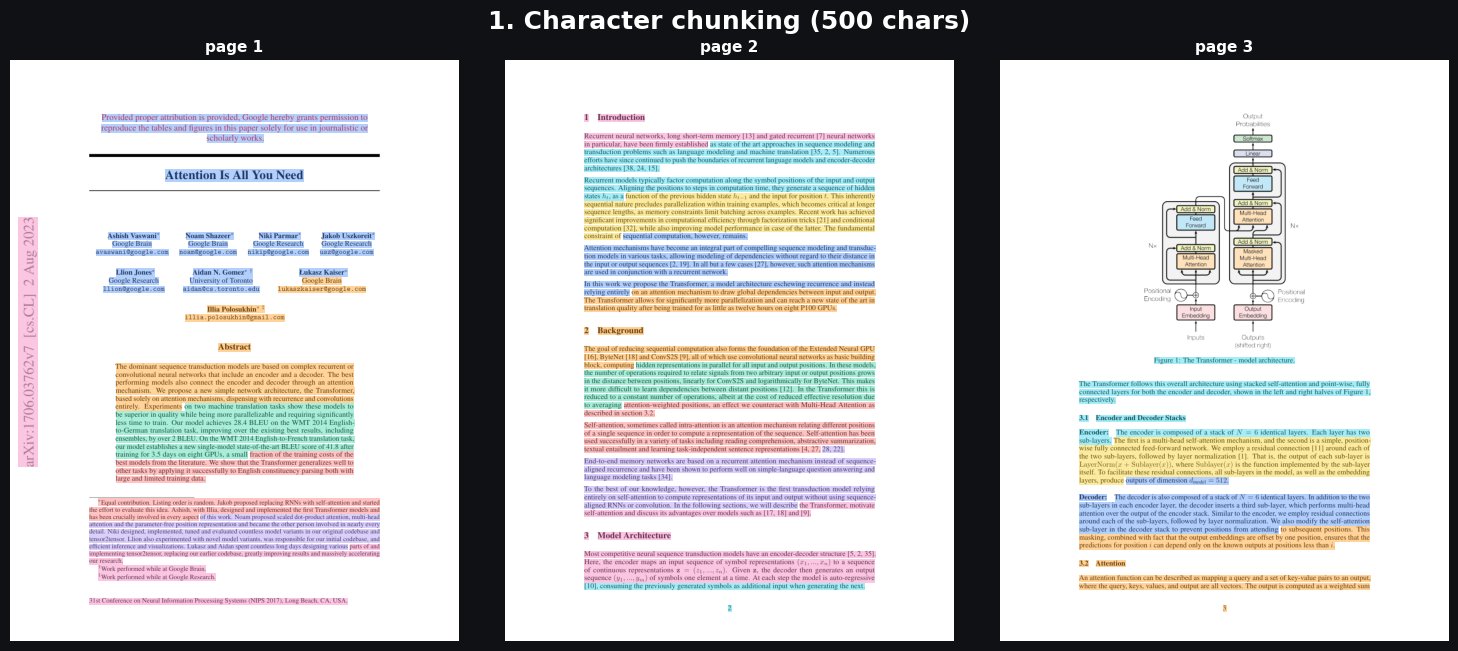

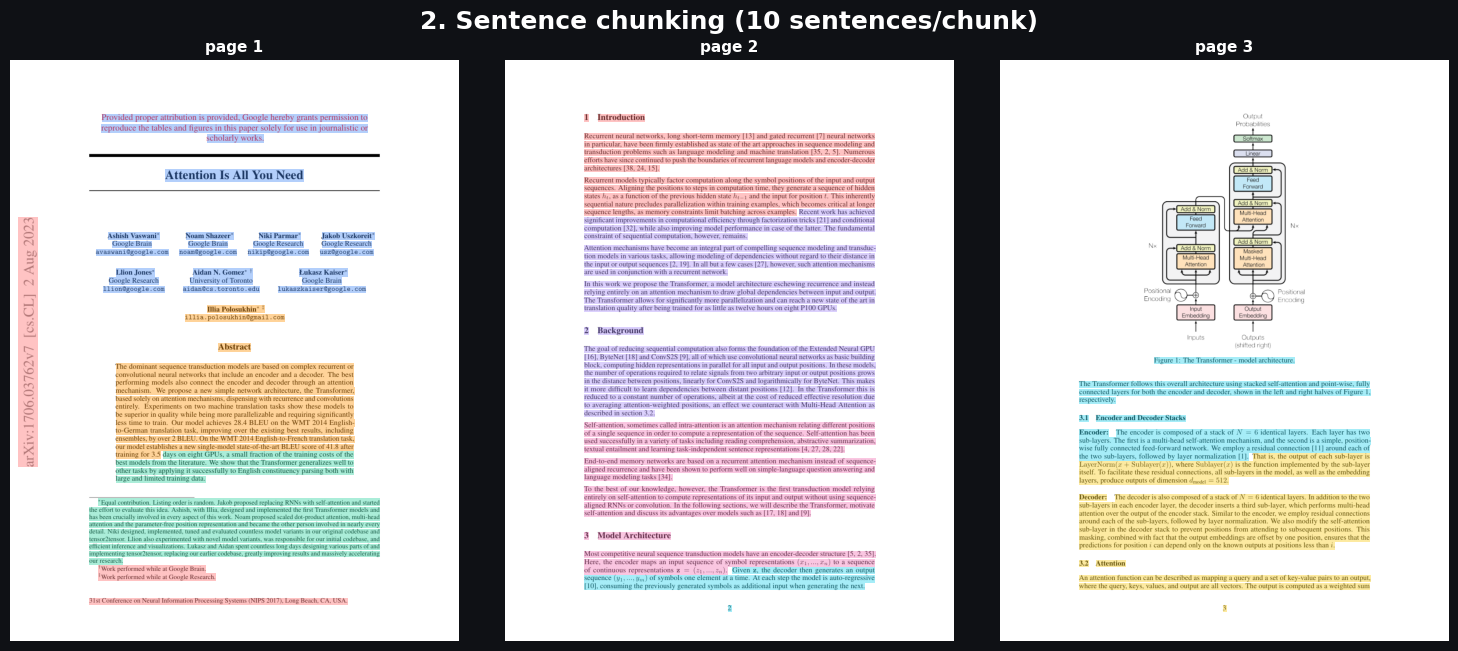

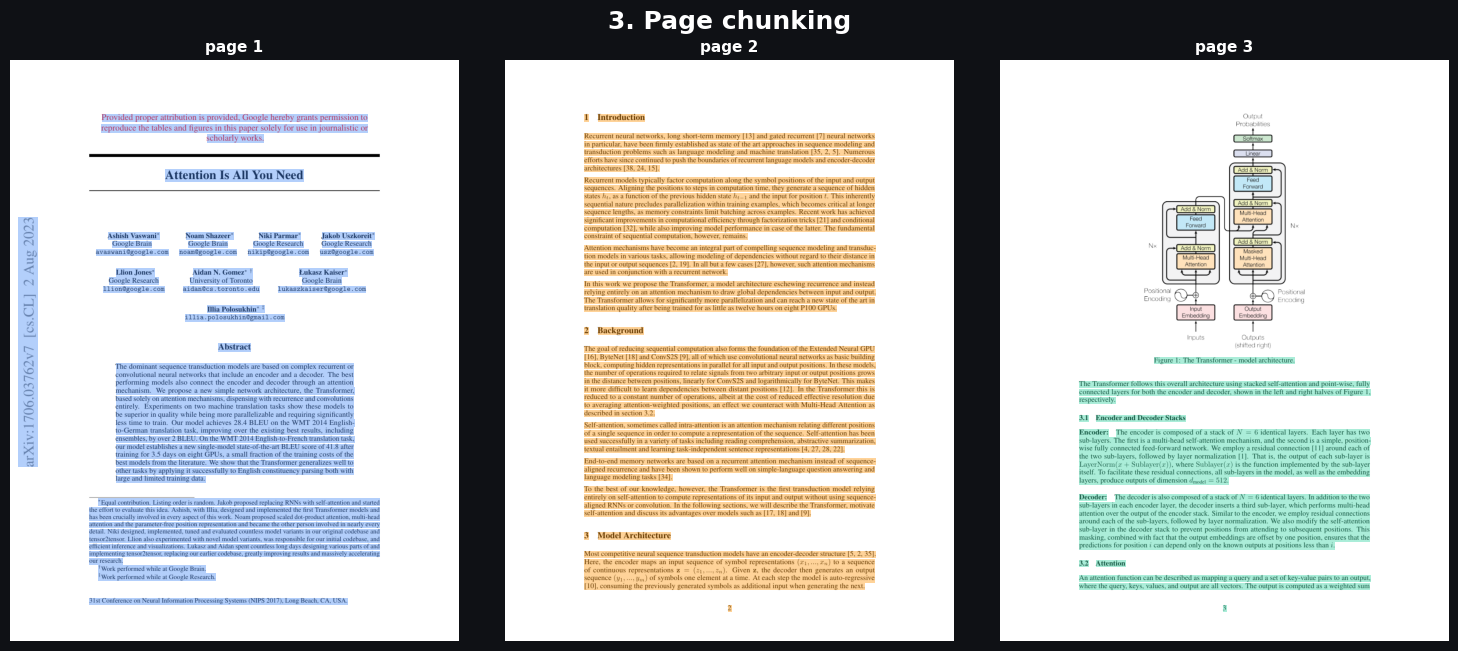

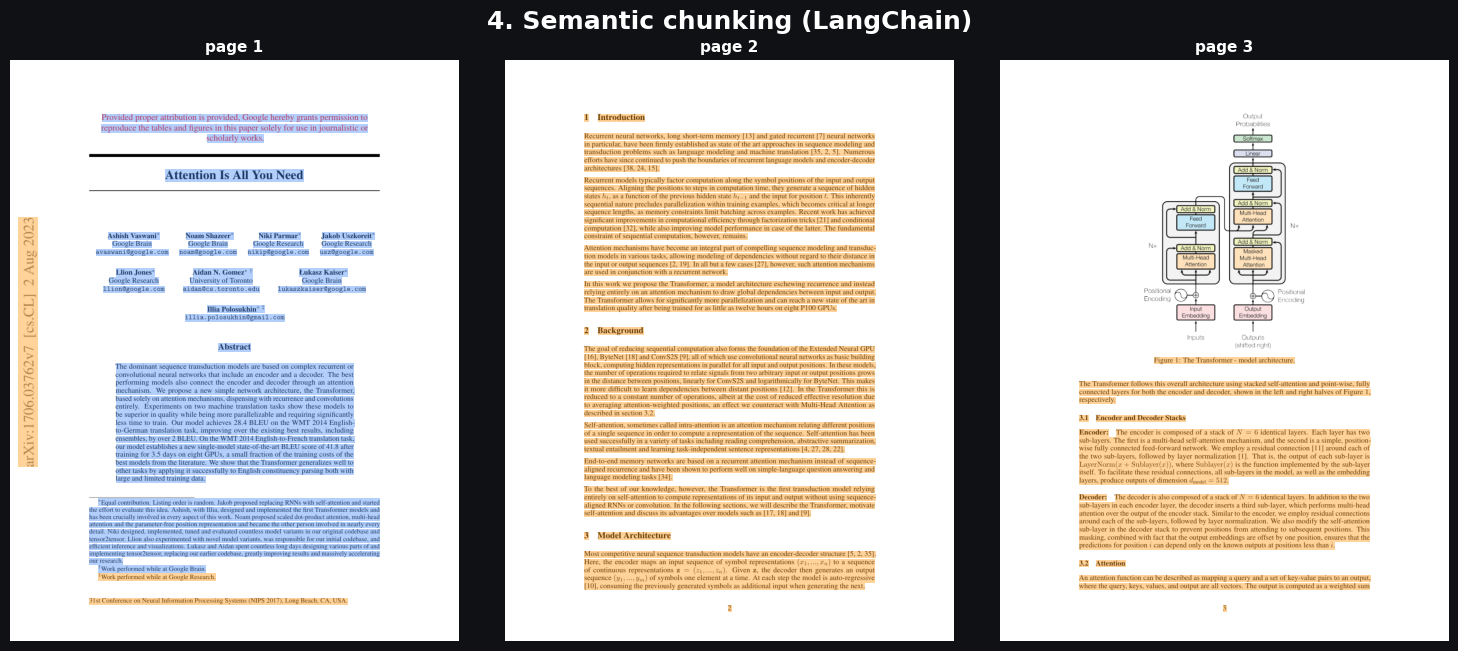

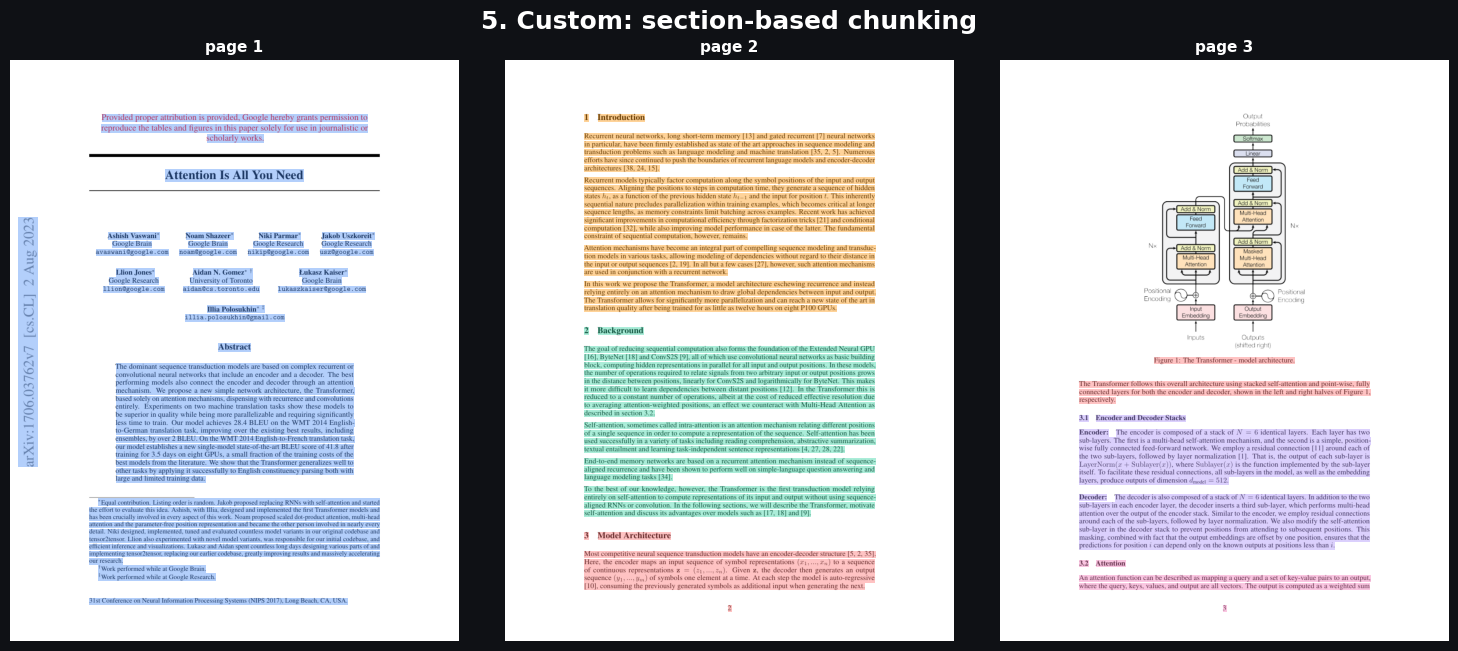

In [12]:
import subprocess, sys
try:
    import fitz
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pymupdf'])
    import fitz

doc = fitz.open(PDF_PATH)

word_offset_map = {}
cursor = 0
for page_idx, page in enumerate(doc):
    for w_idx, w in enumerate(page.get_text('words')):
        w_text = w[4]
        idx = text.find(w_text, cursor)
        if idx == -1:
            idx = text.find(w_text, max(0, cursor - 50))
        if idx == -1:
            continue
        word_offset_map[(page_idx, w_idx)] = idx
        cursor = idx + len(w_text)

def _chunk_index_for(offset, spans):
    for i, (s, e, _) in enumerate(spans):
        if s <= offset < e:
            return i
    return None

def render_chunks_on_pdf(spans, title, palette=PALETTE, max_pages=3, cols=3):
    n_pages = min(max_pages, len(doc))
    rows = (n_pages + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 6.5 * rows),
                             facecolor=BG, squeeze=False)

    for page_idx in range(n_pages):
        ax = axes[page_idx // cols][page_idx % cols]
        page = doc[page_idx]
        pix = page.get_pixmap(dpi=110)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)

        ax.imshow(img)
        ax.set_facecolor(BG)
        ax.set_title(f'page {page_idx + 1}', color='white', fontsize=11, fontweight='bold')
        ax.axis('off')

        words = page.get_text('words')
        if not words:
            continue
        scale = pix.width / page.rect.width

        current = None
        run = []

        def flush(run, chunk_idx):
            if not run or chunk_idx is None:
                return
            color = palette[chunk_idx % len(palette)]
            x0 = min(words[w][0] for w in run) * scale
            y0 = min(words[w][1] for w in run) * scale
            x1 = max(words[w][2] for w in run) * scale
            y1 = max(words[w][3] for w in run) * scale
            ax.add_patch(patches.Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                facecolor=color, edgecolor='none', alpha=0.4
            ))

        prev_line = None
        for w_idx, w in enumerate(words):
            offset = word_offset_map.get((page_idx, w_idx))
            chunk_idx = _chunk_index_for(offset, spans) if offset is not None else None
            line_id = (w[5], w[6])

            if chunk_idx != current or line_id != prev_line:
                flush(run, current)
                run = []
                current = chunk_idx
            run.append(w_idx)
            prev_line = line_id

        flush(run, current)

    for j in range(n_pages, rows * cols):
        axes[j // cols][j % cols].axis('off')

    fig.suptitle(title, color='white', fontsize=18, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

render_chunks_on_pdf(spans_char, '1. Character chunking (500 chars)')
render_chunks_on_pdf(spans_sent, f'2. Sentence chunking ({GROUP} sentences/chunk)')
render_chunks_on_pdf(spans_page, '3. Page chunking')
render_chunks_on_pdf(spans_sem,  '4. Semantic chunking (LangChain)')
render_chunks_on_pdf(spans_cust, '5. Custom: section-based chunking')

## Hierachical Chunking

we are going to establish parent child relationship in the text in 4 steps
1. preserve the space and dehyphenate every line.
2. convert each page into "lines" and detect headings
3. Build hierarchical structure
    - Adds parent_id for each paragraph
    - Adds a parents map for parent re-hydration
    - Replaces offsets with structural locators (loc)
4.  Create child chunks (sentence-aware)
    - Adds parent_id
    - Replaces offsets with structural locators (loc)

In [16]:
import re
from typing import List, Dict, Any

# preserve spaces and dehyphenate the line
def normalize_page(t: str) -> str:
    t = t.replace('\r', '\n')
    # dehyphenate common PDF line breaks: "trans-\nformer" -> "transformer"
    t = re.sub(r'(\w)-\n(\w)', r'\1\2', t)
    # collapse spaces but keep paragraph breaks
    t = re.sub(r'[ \t]+', ' ', t)
    t = re.sub(r'\n{3,}', '\n\n', t)
    return t.strip()

# convert each page into "lines" and detect headings

heading_pattern = re.compile(r'^\s*\d+(\.\d+)*\s+[A-Z]')

def is_heading(line: str) -> bool:
    s = line.strip()
    if not s:
        return False
    if len(s) > 120:
        return False
    return bool(heading_pattern.match(s))


# Sentence splitter
sentence_splitter = re.compile(r'(?<=[.!?])\s+')

def split_sentences(text: str) -> List[str]:
    return [s.strip() for s in sentence_splitter.split(text) if s.strip()]


# Build hierarchical structure
#    - Adds parent_id for each paragraph
#    - Adds a parents map for parent re-hydration
#    - Replaces offsets with structural locators (loc)

def build_hierarchy(pages: List[str], doc_id: str = "doc") -> Dict[str, Any]:
    doc: Dict[str, Any] = {
        "doc_id": doc_id,
        "sections": [],
        "parents": {}  # parent_id -> parent payload (e.g., paragraph text + loc + section title)
    }

    current_section = None
    current_paragraph_lines: List[str] = []

    # Track where we are in the hierarchy
    sec_id = -1
    para_id = 0

    def ensure_fallback_section(page_num: int):
        nonlocal current_section, sec_id, para_id
        if current_section is None:
            sec_id += 1
            para_id = 0
            current_section = {
                "type": "section",
                "section_id": f"{doc_id}_S{sec_id:02d}",
                "title": "Untitled",
                "page_start": page_num,
                "page_end": page_num,
                "paragraphs": []
            }
            doc["sections"].append(current_section)

    def flush_paragraph(page_num: int):
        """
        Flush current paragraph buffer into:
        - section.paragraphs[] with parent_id and loc
        - doc.parents[parent_id] = parent payload
        """
        nonlocal current_paragraph_lines, current_section, para_id

        if not current_paragraph_lines:
            return

        para_text = " ".join(current_paragraph_lines).strip()
        current_paragraph_lines = []

        if not para_text:
            return

        # Make sure we have a section to attach to
        ensure_fallback_section(page_num)

        parent_id = f"{doc_id}_S{sec_id:02d}_P{para_id:04d}"

        # Paragraph locator (stable structural locator)
        para_loc = {
            "doc_id": doc_id,
            "page_start": current_section["page_start"],
            "page_end": page_num,               # paragraph may span pages if your extraction does; here it's within current page loop
            "sec_index": sec_id,
            "para_index": para_id
        }

        paragraph_obj: Dict[str, Any] = {
            "type": "paragraph",
            "parent_id": parent_id,
            "text": para_text,
            "loc": para_loc,
            "sentences": []
        }

        # Sentence level with structural locators
        sentences = split_sentences(para_text)
        for sent_idx, sent in enumerate(sentences):
            paragraph_obj["sentences"].append({
                "type": "sentence",
                "text": sent,
                "loc": {
                    **para_loc,
                    "sent_index": sent_idx
                }
            })

        # Attach paragraph to current section
        current_section["paragraphs"].append(paragraph_obj)

        # Store parent payload (for parent re-hydration)
        doc["parents"][parent_id] = {
            "parent_id": parent_id,
            "type": "parent_paragraph",
            "section_title": current_section["title"],
            "text": para_text,
            "loc": para_loc
        }

        para_id += 1

    for page_i, page in enumerate(pages, start=1):
        page = normalize_page(page)
        lines = page.split('\n')

        for line in lines:
            stripped = line.strip()

            if is_heading(stripped):
                flush_paragraph(page_i)

                sec_id += 1
                para_id = 0
                current_section = {
                    "type": "section",
                    "section_id": f"{doc_id}_S{sec_id:02d}",
                    "title": stripped,
                    "page_start": page_i,
                    "page_end": page_i,
                    "paragraphs": []
                }
                doc["sections"].append(current_section)

            elif stripped == "":
                flush_paragraph(page_i)

            else:
                ensure_fallback_section(page_i)
                current_paragraph_lines.append(stripped)
                current_section["page_end"] = page_i

        flush_paragraph(page_i)

    return doc


In [17]:

# Create child chunks (sentence-aware)
#    - Adds parent_id
#    - Replaces offsets with structural locators (loc)
def create_chunks(doc: Dict[str, Any], max_chars: int = 1200, overlap_sentences: int = 1) -> List[Dict[str, Any]]:
    chunks: List[Dict[str, Any]] = []

    for sec in doc["sections"]:
        for para in sec["paragraphs"]:
            parent_id = para["parent_id"]
            sentences = para["sentences"]

            i = 0
            chunk_id = 0

            while i < len(sentences):
                current_chunk = []
                total_len = 0

                j = i
                while j < len(sentences):
                    s = sentences[j]["text"]
                    if total_len + len(s) > max_chars:
                        break
                    current_chunk.append(sentences[j])
                    total_len += len(s) + 1
                    j += 1

                if not current_chunk:
                    # single long sentence fallback
                    current_chunk = [sentences[i]]
                    j = i + 1

                # Structural locator for chunk
                chunk_loc = {
                    "doc_id": doc["doc_id"],
                    "sec_index": para["loc"]["sec_index"],
                    "para_index": para["loc"]["para_index"],
                    "sent_start": current_chunk[0]["loc"]["sent_index"],
                    "sent_end": current_chunk[-1]["loc"]["sent_index"],
                    "page_start": para["loc"]["page_start"],
                    "page_end": para["loc"]["page_end"]
                }

                chunks.append({
                    "chunk_id": f"{doc['doc_id']}_S{para['loc']['sec_index']:02d}_P{para['loc']['para_index']:04d}_C{chunk_id:03d}",
                    "parent_id": parent_id,
                    "section_title": sec["title"],
                    "text": " ".join(s["text"] for s in current_chunk),
                    "loc": chunk_loc
                })

                chunk_id += 1
                i = max(j - overlap_sentences, i + 1)

    return chunks


In [18]:

# Usage
# ---------------------------
pages_norm = [normalize_page(p) for p in pages]

doc = build_hierarchy(pages_norm, doc_id="paper_001")
chunks = create_chunks(doc)

print(f"Sections: {len(doc['sections'])}")
print(f"Parents (paragraphs): {len(doc['parents'])}")
print(f"Chunks: {len(chunks)}")

print("\n--- Sample chunk ---")
print(chunks[0]["chunk_id"])
print("parent_id:", chunks[0]["parent_id"])
print(chunks[0]["section_title"])
print("loc:", chunks[0]["loc"])
print(chunks[0]["text"][:500])

print("\n--- Sample parent ---")
pid = chunks[0]["parent_id"]
print(pid)
print(doc["parents"][pid]["section_title"])
print("loc:", doc["parents"][pid]["loc"])
print(doc["parents"][pid]["text"][:500])


Sections: 2
Parents (paragraphs): 16
Chunks: 58

--- Sample chunk ---
paper_001_S00_P0000_C000
parent_id: paper_001_S00_P0000
Untitled
loc: {'doc_id': 'paper_001', 'sec_index': 0, 'para_index': 0, 'sent_start': 0, 'sent_end': 5, 'page_start': 1, 'page_end': 1}
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. Attention Is All You Need Ashish Vaswani∗ Google Brain avaswani@google.com Noam Shazeer∗ Google Brain noam@google.com Niki Parmar∗ Google Research nikip@google.com Jakob Uszkoreit∗ Google Research usz@google.com Llion Jones∗ Google Research llion@google.com Aidan N. Gomez∗† University of Toronto aidan@cs.toronto.edu Łukasz K

--- Sample parent ---
paper_001_S00_P0000
Untitled
loc: {'doc_id': 'paper_001', 'page_start': 1, 'page_end': 1, 'sec_index': 0, 'para_index': 0}
Provided proper attribution is provided, Google hereby grants permission to reproduce the ta

In [19]:
# Build hierarchical spans from paragraph parents
# NOTE: This is intentionally heuristic, for visualisation only

def parents_to_spans(text, parents):
    """
    Convert hierarchical parent paragraphs into (start, end, label) spans
    using best-effort substring matching.

    This mirrors docs_to_spans() and is suitable for research / visualisation,
    NOT for citation-grade offsets.
    """
    spans = []
    cursor = 0

    for k, (parent_id, parent) in enumerate(parents.items()):
        content = parent["text"]

        idx = text.find(content, cursor)
        if idx == -1:
            # fallback: partial match
            idx = text.find(content[:max(50, len(content)//4)], cursor)

        if idx == -1:
            idx = cursor  # last-resort fallback

        end = idx + len(content)
        label = f'para_{k:03d}'

        spans.append((idx, end, label))
        cursor = end

    return spans

spans_hier = parents_to_spans(text, doc["parents"])
print(f'{len(spans_hier)} hierarchical parent chunks\n')

for s, e, lbl in spans_hier[:5]:
    print(f'[{s}:{e}] {e-s:,} chars | {lbl}')

16 hierarchical parent chunks

[0:2853] 2,853 chars | para_000
[2856:7105] 4,249 chars | para_001
[7112:8936] 1,824 chars | para_002
[8939:11444] 2,505 chars | para_003
[11447:14637] 3,190 chars | para_004


## Comparison

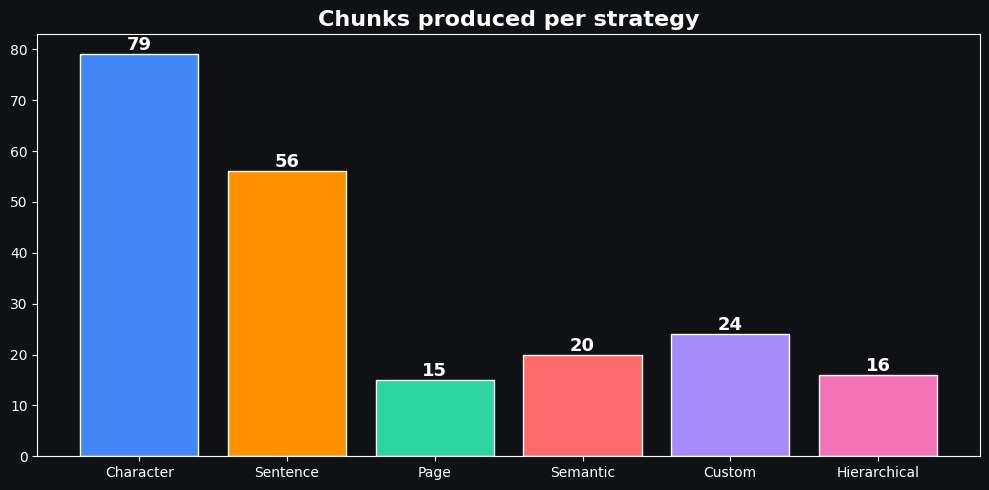

In [20]:
strategies = [
    ('Character',  spans_char),
    ('Sentence',   spans_sent),
    ('Page',       spans_page),
    ('Semantic',   spans_sem),
    ('Custom',     spans_cust),
    ('Hierarchical', spans_hier),
]

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
ax.set_facecolor(BG)
names  = [s[0] for s in strategies]
counts = [len(s[1]) for s in strategies]
bars = ax.bar(names, counts, color=PALETTE[:len(names)], edgecolor='white')
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(counts)*0.01,
            str(c), ha='center', color='white', fontsize=13, fontweight='bold')
ax.set_title('Chunks produced per strategy', color='white',
             fontsize=16, fontweight='bold')
ax.tick_params(colors='white'); [s.set_color('white') for s in ax.spines.values()]
plt.tight_layout(); plt.show()

### Which to use

| Strategy | Strength | Weakness |
|---|---|---|
| Character | fastest, deterministic | splits mid-word |
| Sentence | preserves grammar | wildly varying chunk sizes |
| Page | respects document structure | pages can be huge or tiny |
| Semantic | chunks match topics | embedding cost, tune threshold |
| Custom (recursive + overlap) | best quality for RAG | more params to tune |

---

**Share this notebook:** `File -> Save a copy in GitHub` or `File -> Share` in Colab.